In [3]:
import pandas as pd
import numpy as np

REF_CSV = "../data/res/calibration/reference.csv"   # 改成你的路径

df = pd.read_csv(REF_CSV)

z = df["z_evidence"].dropna().to_numpy(dtype=float)

# ===== helper =====
def mad(x):
    med = np.median(x)
    return 1.4826 * np.median(np.abs(x - med))

def trimmed_mean(x, p=0.1):
    x = np.sort(x)
    n = len(x)
    k = int(n * p)
    return np.mean(x[k:n-k])

# ===== stats =====
med = np.median(z)
mean = np.mean(z)
std = np.std(z)
mad_val = mad(z)

print("=== reference stats ===")
print(f"n        : {len(z)}")
print(f"mean     : {mean:.6f}")
print(f"median   : {med:.6f}")
print(f"std      : {std:.6f}")
print(f"mad      : {mad_val:.6f}")

print("\n=== nu candidates ===")
print(f"median                  : {med:.6f}")
print(f"mean                    : {mean:.6f}")
print(f"q75                     : {np.quantile(z, 0.75):.6f}")
print(f"q80                     : {np.quantile(z, 0.80):.6f}")
print(f"q90                     : {np.quantile(z, 0.90):.6f}")
print(f"q95                     : {np.quantile(z, 0.95):.6f}")
print(f"q99                     : {np.quantile(z, 0.99):.6f}")
print(f"trimmed_mean_10         : {trimmed_mean(z, 0.10):.6f}")
print(f"trimmed_mean_20         : {trimmed_mean(z, 0.20):.6f}")
print(f"median_plus_half_mad    : {med + 0.5 * mad_val:.6f}")
print(f"median_plus_mad         : {med + 1.0 * mad_val:.6f}")
print(f"mean_plus_half_std      : {mean + 0.5 * std:.6f}")
print(f"mean_plus_std           : {mean + 1.0 * std:.6f}")

=== reference stats ===
n        : 192
mean     : 1.929215
median   : 1.409168
std      : 1.749547
mad      : 1.443924

=== nu candidates ===
median                  : 1.409168
mean                    : 1.929215
q75                     : 2.687044
q80                     : 3.255650
q90                     : 4.378023
q95                     : 5.307040
q99                     : 8.040474
trimmed_mean_10         : 1.672009
trimmed_mean_20         : 1.539770
median_plus_half_mad    : 2.131130
median_plus_mad         : 2.853092
mean_plus_half_std      : 2.803989
mean_plus_std           : 3.678762


In [5]:
import pandas as pd
import numpy as np

TEST_CSV = "../data/res/calibration/test.csv"

df = pd.read_csv(TEST_CSV).sort_values("block_index")

z = df["z_evidence"].to_numpy(dtype=float)

# ===== v candidate =====
nu_dict = {
    "mean": 1.929215,
    "q75": 2.687044,
    "median_plus_mad": 2.853092,
    "q90": 4.378023,
    "q95": 5.307040,
    "q99": 8.040474
}

def compute_g(z, nu):
    g = []
    cur = 0.0
    for val in z:
        cur = max(0.0, cur + val - nu)
        g.append(cur)
    return np.array(g)

print("=== G_t behavior ===")

for name, nu in nu_dict.items():
    g = compute_g(z, nu)
    inc = z - nu

    print(f"\n[{name}]")
    print(f"nu = {nu:.6f}")
    print(f"pos_ratio      = {np.mean(inc > 0):.4f}")
    print(f"mean_increment = {np.mean(inc):.6f}")
    print(f"g_final        = {g[-1]:.6f}")
    print(f"g_max          = {np.max(g):.6f}")

=== G_t behavior ===

[mean]
nu = 1.929215
pos_ratio      = 0.9523
mean_increment = 4.608619
g_final        = 9279.033840
g_max          = 9279.033840

[q75]
nu = 2.687044
pos_ratio      = 0.9086
mean_increment = 3.850790
g_final        = 7755.686784
g_max          = 7755.686784

[median_plus_mad]
nu = 2.853092
pos_ratio      = 0.8987
mean_increment = 3.684742
g_final        = 7422.096352
g_max          = 7422.096352

[q90]
nu = 4.378023
pos_ratio      = 0.7551
mean_increment = 2.159811
g_final        = 4422.000856
g_max          = 4422.000856

[q95]
nu = 5.307040
pos_ratio      = 0.6895
mean_increment = 1.230794
g_final        = 2699.931458
g_max          = 2699.931458

[q99]
nu = 8.040474
pos_ratio      = 0.3438
mean_increment = -1.502640
g_final        = 61.940284
g_max          = 108.821744


1. compute v from reference

In [20]:
import pandas as pd
import numpy as np

# load reference
ref_df = "../data/res/calibration/reference.csv"
df = pd.read_csv(ref_df)

z_ref = df["z_evidence"].values

nu_dict = {
    "1sigma": np.quantile(z_ref, 0.683),
    "2sigma": np.quantile(z_ref, 0.954),
    "3sigma": np.quantile(z_ref, 0.997)
}

print("=== nu values ===")
for k, v in nu_dict.items():
    print(f"{k}: {v:.6f}")

=== nu values ===
1sigma: 2.382942
2sigma: 5.383472
3sigma: 8.213607


In [21]:
TEST_CSV = "../data/res/calibration/test.csv"

test_df = pd.read_csv(TEST_CSV).sort_values("block_index")


z = test_df["z_evidence"].values

# optional: if you have performance
if "f1_score" in test_df.columns:
    f1 = test_df["f1_score"].values
else:
    f1 = None

In [22]:
def simulate_gt(z, nu, h):
    G = 0.0
    triggers = []
    G_series = []

    for t in range(len(z)):
        G = max(0.0, G + (z[t] - nu))
        G_series.append(G)

        if G > h:
            triggers.append(t)
            G = 0.0  # reset after trigger

    return np.array(G_series), triggers

In [23]:
def evaluate(z, f1, nu, h):
    G_series, triggers = simulate_gt(z, nu, h)

    T = len(z)
    n_trig = len(triggers)

    trigger_rate = n_trig / T if T > 0 else 0.0

    if n_trig > 1:
        intervals = np.diff(triggers)
        mean_interval = intervals.mean()
    else:
        mean_interval = np.nan

    # performance before trigger
    if f1 is not None and n_trig > 0:
        f1_before = [f1[t-1] for t in triggers if t > 0]
        avg_f1_before = np.mean(f1_before) if len(f1_before) > 0 else np.nan
    else:
        avg_f1_before = np.nan

    return {
        "nu": nu,
        "h": h,
        "trigger_rate": trigger_rate,
        "n_triggers": n_trig,
        "mean_interval": mean_interval,
        "avg_f1_before_trigger": avg_f1_before,
    }

In [24]:
h_list = [2, 4, 6, 8, 10, 15, 20]

results = []

for nu_name, nu_value in nu_dict.items():
    for h in h_list:
        metrics = evaluate(z, f1, nu_value, h)
        metrics["nu_name"] = nu_name
        results.append(metrics)

res_df = pd.DataFrame(results)

In [25]:
pd.set_option("display.float_format", "{:.4f}".format)

print("\n=== RQ2 Calibration Results ===\n")
print(res_df.sort_values(["nu_name", "h"]))


=== RQ2 Calibration Results ===

       nu   h  trigger_rate  n_triggers  mean_interval  avg_f1_before_trigger  \
0  2.3829   2        0.7829        1576         1.2749                 0.8572   
1  2.3829   4        0.6538        1316         1.5262                 0.8517   
2  2.3829   6        0.5072        1021         1.9667                 0.8460   
3  2.3829   8        0.3761         757         2.6521                 0.8505   
4  2.3829  10        0.3249         654         3.0658                 0.8490   
5  2.3829  15        0.2295         462         4.3319                 0.8441   
6  2.3829  20        0.1828         368         5.4360                 0.8437   
7  5.3835   2        0.4719         950         2.0980                 0.8332   
8  5.3835   4        0.2976         599         3.2893                 0.8231   
9  5.3835   6        0.2027         408         4.6978                 0.8169   
10 5.3835   8        0.1590         320         5.9937                 0.80

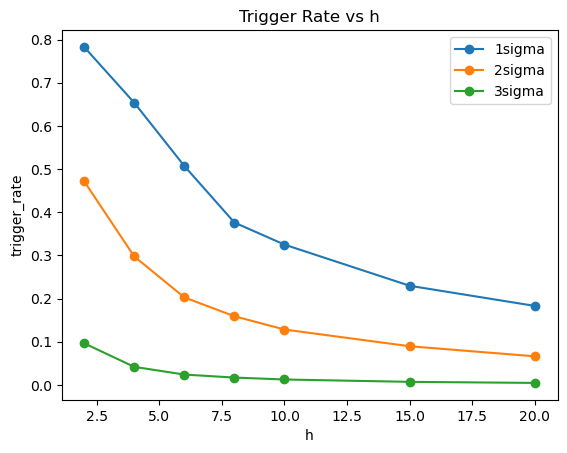

In [26]:
import matplotlib.pyplot as plt

plt.figure()

for nu_name in res_df["nu_name"].unique():
    sub = res_df[res_df["nu_name"] == nu_name]
    plt.plot(sub["h"], sub["trigger_rate"], marker="o", label=nu_name)

plt.xlabel("h")
plt.ylabel("trigger_rate")
plt.title("Trigger Rate vs h")
plt.legend()
plt.show()